# Image inspection and Conversion
I would like to do this seperately before running the model. Manually converting and checking images so they are in correct format and can feed into the model directly.

## Loading files from local to RetiFluidNet folder

In [2]:
from pathlib import Path
import shutil
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

source_base = Path(r'D:\GradApp\BIDS@I2DB\lab_works\RETOUCH\RETOUCH-TrainingSet-Cirrus') # Change it to where you save the files locally
dest_bscan   = Path(r'C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\raw_bscans')
dest_mask    = Path(r'C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\raw_masks')

dest_bscan.mkdir(parents=True, exist_ok=True)
dest_mask.mkdir(parents=True, exist_ok=True)

mapping = [
    ('oct', dest_bscan, '_oct'),
    ('reference', dest_mask,  '_mask'),
]

for idx in range(1, 25):
    train_id = f'TRAIN{idx:03d}'
    src_dir = source_base / train_id

    for src_stem, dest_dir, suffix in mapping:
        src_mhd = src_dir / f"{src_stem}.mhd"
        src_raw = src_dir / f"{src_stem}.raw"

        dest_mhd = dest_dir / f"{train_id}{suffix}.mhd"
        dest_raw = dest_dir / f"{train_id}{suffix}.raw"

        shutil.copy2(src_mhd, dest_mhd)
        text = dest_mhd.read_text().splitlines()
        with open(dest_mhd, 'w', newline='\n') as f:
            for line in text:
                if line.strip().startswith('ElementDataFile'):
                    f.write(f"ElementDataFile = {dest_raw.name}\n")
                else:
                    f.write(line + "\n")

        if src_raw.exists():
            shutil.copy2(src_raw, dest_raw)
            print(f"Copied files to {dest_raw.name}")
        else:
            print(f"Files not found: {src_raw}")

Copied files to TRAIN001_oct.raw
Copied files to TRAIN001_mask.raw
Copied files to TRAIN002_oct.raw
Copied files to TRAIN002_mask.raw
Copied files to TRAIN003_oct.raw
Copied files to TRAIN003_mask.raw
Copied files to TRAIN004_oct.raw
Copied files to TRAIN004_mask.raw
Copied files to TRAIN005_oct.raw
Copied files to TRAIN005_mask.raw
Copied files to TRAIN006_oct.raw
Copied files to TRAIN006_mask.raw
Copied files to TRAIN007_oct.raw
Copied files to TRAIN007_mask.raw
Copied files to TRAIN008_oct.raw
Copied files to TRAIN008_mask.raw
Copied files to TRAIN009_oct.raw
Copied files to TRAIN009_mask.raw
Copied files to TRAIN010_oct.raw
Copied files to TRAIN010_mask.raw
Copied files to TRAIN011_oct.raw
Copied files to TRAIN011_mask.raw
Copied files to TRAIN012_oct.raw
Copied files to TRAIN012_mask.raw
Copied files to TRAIN013_oct.raw
Copied files to TRAIN013_mask.raw
Copied files to TRAIN014_oct.raw
Copied files to TRAIN014_mask.raw
Copied files to TRAIN015_oct.raw
Copied files to TRAIN015_mask

In [6]:
print("Current working directory:", os.getcwd())

# MHD header reader
def read_mhd_header(mhd_path):
    header = {}
    with open(mhd_path, 'r') as f:
        for line in f:
            line = line.strip()
            if '=' in line:
                key, val = line.split('=', 1)
                header[key.strip()] = val.strip()
    return header

# Read raw volume into NumPy array and reshape to Z, Y, X
def read_mhd_volume(mhd_path):
    hdr = read_mhd_header(mhd_path)
    dim_x, dim_y, dim_z = map(int, hdr['DimSize'].split())
    dtype_map = {
        'MET_UCHAR':  np.uint8,  'MET_USHORT': np.uint16,
    }
    et = hdr.get('ElementType', 'MET_UCHAR')
    raw_path = mhd_path.parent / hdr['ElementDataFile']
    arr = np.fromfile(raw_path, dtype=dtype_map[et])
    vol = arr.reshape((dim_z, dim_y, dim_x))
    return vol, hdr

Current working directory: C:\Users\sunxi\RetiFluidNet_CPU


In [8]:
# Check file directory 
cirrus = Path(os.getcwd()) / 'RetouchData' / 'Cirrus' 
raw_oct_dir = cirrus / 'raw_bscans'
raw_mask_dir = cirrus / 'raw_masks'

print("OCT files in raw_bscans:")
for f in sorted(raw_oct_dir.glob('*.mhd')):
    print('-', f.name)
print("\nMask files in raw_masks:")
for f in sorted(raw_mask_dir.glob('*.mhd')):
    print('-', f.name)

OCT files in raw_bscans:
- TRAIN001_oct.mhd
- TRAIN002_oct.mhd
- TRAIN003_oct.mhd
- TRAIN004_oct.mhd
- TRAIN005_oct.mhd
- TRAIN006_oct.mhd
- TRAIN007_oct.mhd
- TRAIN008_oct.mhd
- TRAIN009_oct.mhd
- TRAIN010_oct.mhd
- TRAIN011_oct.mhd
- TRAIN012_oct.mhd
- TRAIN013_oct.mhd
- TRAIN014_oct.mhd
- TRAIN015_oct.mhd
- TRAIN016_oct.mhd
- TRAIN017_oct.mhd
- TRAIN018_oct.mhd
- TRAIN019_oct.mhd
- TRAIN020_oct.mhd
- TRAIN021_oct.mhd
- TRAIN022_oct.mhd
- TRAIN023_oct.mhd
- TRAIN024_oct.mhd

Mask files in raw_masks:
- TRAIN001_mask.mhd
- TRAIN002_mask.mhd
- TRAIN003_mask.mhd
- TRAIN004_mask.mhd
- TRAIN005_mask.mhd
- TRAIN006_mask.mhd
- TRAIN007_mask.mhd
- TRAIN008_mask.mhd
- TRAIN009_mask.mhd
- TRAIN010_mask.mhd
- TRAIN011_mask.mhd
- TRAIN012_mask.mhd
- TRAIN013_mask.mhd
- TRAIN014_mask.mhd
- TRAIN015_mask.mhd
- TRAIN016_mask.mhd
- TRAIN017_mask.mhd
- TRAIN018_mask.mhd
- TRAIN019_mask.mhd
- TRAIN020_mask.mhd
- TRAIN021_mask.mhd
- TRAIN022_mask.mhd
- TRAIN023_mask.mhd
- TRAIN024_mask.mhd


## Grab an example and investigate

In [10]:
# Load an example patient (13, 20)
example_oct = sorted(raw_oct_dir.glob('*.mhd'))[12]
oct_vol, oct_hdr = read_mhd_volume(example_oct)
mask_path = raw_mask_dir / example_oct.name.replace('_oct.mhd', '_mask.mhd')
mask_vol, mask_hdr = read_mhd_volume(mask_path)

print(f"Loaded OCT: {example_oct.name}")
print(f"OCT shape (Z, Y, X): {oct_vol.shape}")
print(f"OCT sum: {np.sum(oct_vol)}")
print("OCT intensity range:", oct_vol.min(), "to", oct_vol.max())
print(oct_hdr)


print(f"Mask shape (Z, Y, X): {mask_vol.shape}")
print(f"Mask sum: {np.sum(mask_vol)}")
print("Mask labels range:", mask_vol.min(), "to", mask_vol.max())
print(mask_hdr)

Loaded OCT: TRAIN013_oct.mhd
OCT shape (Z, Y, X): (128, 1024, 512)
OCT sum: 2178407814
OCT intensity range: 0 to 178
{'ObjectType': 'Image', 'NDims': '3', 'BinaryData': 'True', 'BinaryDataByteOrderMSB': 'False', 'CompressedData': 'False', 'TransformMatrix': '1  0  0  0  1  0  0  0  1', 'CenterOfRotation': '0  0  0', 'AnatomicalOrientation': 'RAI', 'Offset': '0  0  0', 'ElementSpacing': '0.011742     0.001955     0.047244', 'DimSize': '512  1024   128', 'ElementNumberOfChannels': '1', 'ElementType': 'MET_UCHAR', 'ElementDataFile': 'TRAIN013_oct.raw'}
Mask shape (Z, Y, X): (128, 1024, 512)
Mask sum: 1338905
Mask labels range: 0 to 3
{'ObjectType': 'Image', 'NDims': '3', 'BinaryData': 'True', 'BinaryDataByteOrderMSB': 'False', 'CompressedData': 'False', 'TransformMatrix': '1  0  0  0  1  0  0  0  1', 'CenterOfRotation': '0  0  0', 'AnatomicalOrientation': 'RAI', 'Offset': '0  0  0', 'ElementSpacing': '0.011742     0.001955     0.047244', 'DimSize': '512  1024   128', 'ElementNumberOfChann

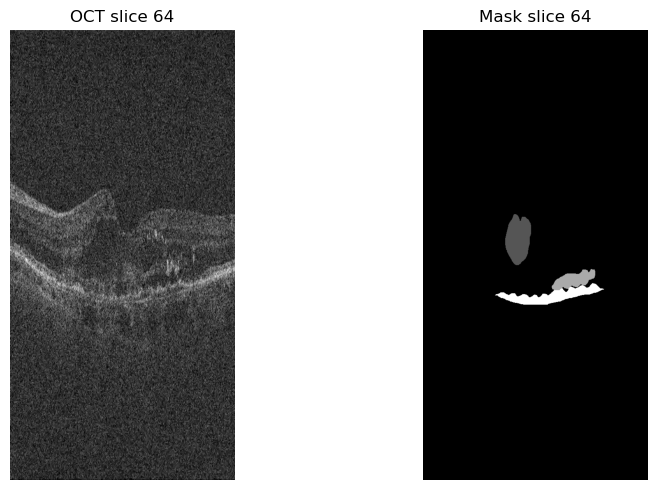

In [12]:
# Visualize Slices
slice_idx = 64
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(oct_vol[slice_idx], cmap='gray')
axes[0].set_title(f'OCT slice {slice_idx}')
axes[0].axis('off')

axes[1].imshow(mask_vol[slice_idx], cmap='gray')
axes[1].set_title(f'Mask slice {slice_idx}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## original OCT bscans

In [15]:
# Full matrix for OCT bscan
print("OCT slice matrix at slice", slice_idx)
print(f"OCT sum: {np.sum(oct_vol[slice_idx])}")
print(oct_vol[24][150:300])

OCT slice matrix at slice 64
OCT sum: 17178814
[[ 4 28 31 ... 19 28 37]
 [13 37 44 ... 25 28 32]
 [24 48 58 ... 32 30 28]
 ...
 [30 30 28 ... 31 16 42]
 [44 44 35 ... 17 27 38]
 [27 27 31 ... 26 29 33]]


## original masks come with pixel of range [0, 1, 2, 3]

In [18]:
# Matrix of masks
np.set_printoptions(threshold=np.inf)
print("Mask slice matrix at slice index:", slice_idx)
print(f"Mask sum: {np.sum(mask_vol[slice_idx])}")
print(mask_vol[24][150:300])

Mask slice matrix at slice index: 64
Mask sum: 24517
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

## Convert the raw images to the format the model want, bscan to jpg, masks to gif

In [21]:
# Image conversion, from raw to jpg and gif
oct_root      = cirrus / 'retouch_data'
mask_root     = cirrus / 'retouch_data_mask'
gray_levels   = np.array([0, 85, 170, 255], dtype=np.uint8)

for oct_mhd in sorted(raw_oct_dir.glob('*_oct.mhd')):
    stem = oct_mhd.stem.replace('_oct', '') 

    # Load volumes for this patient
    oct_vol, _    = read_mhd_volume(oct_mhd)
    mask_path     = raw_mask_dir / f"{stem}_mask.mhd"
    mask_vol, _   = read_mhd_volume(mask_path)

    # Make patient subdirs
    patient_oct_dir  = oct_root / stem
    patient_mask_dir = mask_root / stem
    patient_oct_dir.mkdir(parents=True, exist_ok=True)
    patient_mask_dir.mkdir(parents=True, exist_ok=True)

    oct_min, oct_max = oct_vol.min(), oct_vol.max()

    for z in range(oct_vol.shape[0]):
        # OCT to JPG
        slice_img = oct_vol[z].astype(np.float32)
        norm      = (slice_img - oct_min) / (oct_max - oct_min)
        jpg       = (norm * 255.0).clip(0,255).astype(np.uint8)
        Image.fromarray(jpg, mode='L') \
             .save(patient_oct_dir / f"{stem}_oct_{z:03d}.jpg")

        # Mask to GIF (0,85,170,255)
        labels = mask_vol[z].astype(np.uint8)
        gray   = gray_levels[labels]
        Image.fromarray(gray, mode='L') \
             .save(patient_mask_dir / f"{stem}_mask_{z:03d}.gif")

    print(f"Patient {stem}: saved {oct_vol.shape[0]} slices to\n"
          f"  OCT JPGs → {patient_oct_dir}\n"
          f"  Mask GIFs → {patient_mask_dir}")

Patient TRAIN001: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\retouch_data\TRAIN001
  Mask GIFs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\retouch_data_mask\TRAIN001
Patient TRAIN002: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\retouch_data\TRAIN002
  Mask GIFs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\retouch_data_mask\TRAIN002
Patient TRAIN003: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\retouch_data\TRAIN003
  Mask GIFs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\retouch_data_mask\TRAIN003
Patient TRAIN004: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\retouch_data\TRAIN004
  Mask GIFs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\retouch_data_mask\TRAIN004
Patient TRAIN005: saved 128 slices to
  OCT JPGs → C:\Users\sunxi\RetiFluidNet_CPU\RetouchData\Cirrus\retouch_data\TRAIN005
  Mask GIFs 

## Check the converted images

OCT JPG slice 64:
Shape: (1024, 512) Sum: 24360413
Mask GIF slice 64:
Shape: (1024, 512) Sum: 2083945
Unique gray levels: [  0  85 170 255]


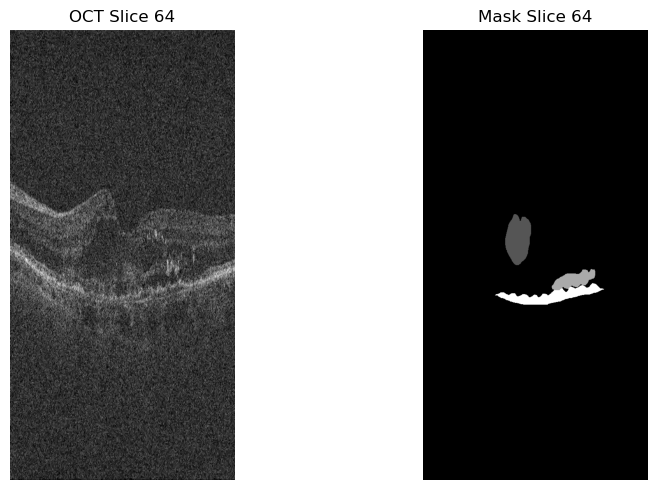

Mask
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [23]:
example = 'TRAIN013'

jpg_path = oct_root  / example / f"{example}_oct_{slice_idx:03d}.jpg"
gif_path = mask_root / example / f"{example}_mask_{slice_idx:03d}.gif"

jpg_arr = np.array(Image.open(jpg_path).convert('L'))
gif_arr = np.array(Image.open(gif_path).convert('L'))

np.set_printoptions(threshold=np.inf, linewidth=200)

print(f"OCT JPG slice {slice_idx}:")
print("Shape:", jpg_arr.shape, "Sum:", jpg_arr.sum())

print(f"Mask GIF slice {slice_idx}:")
print("Shape:", gif_arr.shape, "Sum:", gif_arr.sum())
print("Unique gray levels:", np.unique(gif_arr))


# Side‐by‐side plot
plt.figure(figsize=(10, 5))
# OCT
plt.subplot(1, 2, 1)
plt.imshow(jpg_arr, cmap='gray')
plt.title(f'OCT Slice {slice_idx}')
plt.axis('off')
# Mask
plt.subplot(1, 2, 2)
plt.imshow(gif_arr, cmap='gray')
plt.title(f'Mask Slice {slice_idx}')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Mask\n", gif_arr)
print("OCT\n", jpg_arr)